<a href="https://colab.research.google.com/github/chantika-maharani/regresi_5C_Kelompok4/blob/main/ML_TIM_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. EDA

In [2]:
# Menginstal library Kaggle agar dataset dari Kaggle
!pip install -q kaggle

Penjelasan: Kode ini digunakan untuk menginstal library Kaggle agar dataset dapat diunduh langsung melalui notebook.

In [3]:
# Mengatur Environment Variable untuk API Token
import os
import getpass

print("Silakan tempel (paste) API Token Kaggle Anda (dimulai dengan KGAT_...) dan tekan Enter:")
# getpass digunakan agar token yang Anda ketik tidak terlihat di layar
kaggle_token = getpass.getpass('KAGGLE_API_TOKEN: ')

# Menyetel environment variable agar library kaggle bisa membacanya
os.environ['KAGGLE_API_TOKEN'] = kaggle_token

print("\nOtentikasi API Kaggle Selesai!")

Silakan tempel (paste) API Token Kaggle Anda (dimulai dengan KGAT_...) dan tekan Enter:
KAGGLE_API_TOKEN: ··········

Otentikasi API Kaggle Selesai!


Penjelasan: Kode ini digunakan untuk menyimpan token API Kaggle sebagai autentikasi agar notebook dapat mengakses dataset dari Kaggle. Token asli sebaiknya tidak dibagikan.

In [4]:
# Mengunduh dataset California Housing Prices
# dari Kaggle
!kaggle datasets download -d camnugent/california-housing-prices

Dataset URL: https://www.kaggle.com/datasets/camnugent/california-housing-prices
License(s): CC0-1.0
100% 400k/400k [00:00<00:00, 60.5MB/s]



Penjelasan: Kode ini digunakan untuk mengunduh dataset California Housing Prices dari Kaggle dalam bentuk file ZIP.

In [5]:
import zipfile

# Membuka file ZIP dataset
with zipfile.ZipFile("california-housing-prices.zip", "r") as zip_ref:

    # Mengekstrak seluruh isi ZIP ke folder california_housing
    zip_ref.extractall("california_housing")

Penjelasan: Kode ini digunakan untuk mengekstrak file ZIP ke folder california_housing agar dataset dapat digunakan.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur tampilan grafik Seaborn
sns.set_theme(style='whitegrid')

# Membaca dataset housing.csv
df = pd.read_csv('california_housing/housing.csv')

# Menampilkan 5 data pertama
print(df.head())

# Menampilkan jumlah baris dan kolom
print(df.shape)

# Menampilkan informasi dataset
df.info()

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  
(20640, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries

Penjelasan: Kode ini digunakan untuk mengimpor library, membaca dataset, menampilkan lima data pertama, melihat ukuran dataset, dan memeriksa tipe data serta informasi setiap kolom.

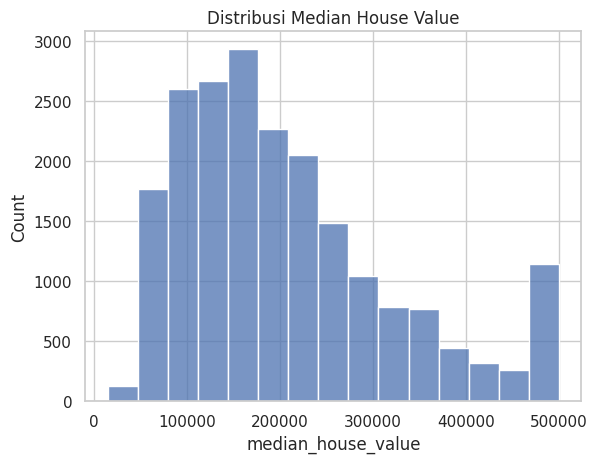

In [7]:
# Membuat histogram untuk melihat distribusi harga rumah
sns.histplot(data=df, x='median_house_value', bins=15)

plt.title('Distribusi Median House Value')
plt.show()

Penjelasan: Kode ini membuat histogram untuk melihat penyebaran harga rumah pada kolom median_house_value.

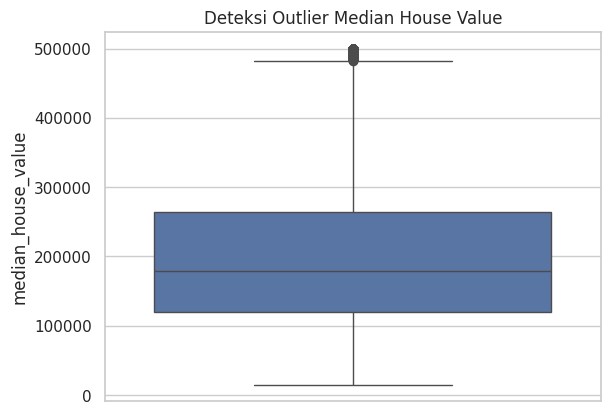

In [8]:
# Membuat boxplot untuk melihat kemungkinan outlier
sns.boxplot(data=df, y='median_house_value')

plt.title('Deteksi Outlier Median House Value')
plt.show()

Penjelasan: Kode ini membuat boxplot untuk melihat distribusi harga rumah sekaligus mendeteksi adanya data yang terlalu jauh atau outlier.

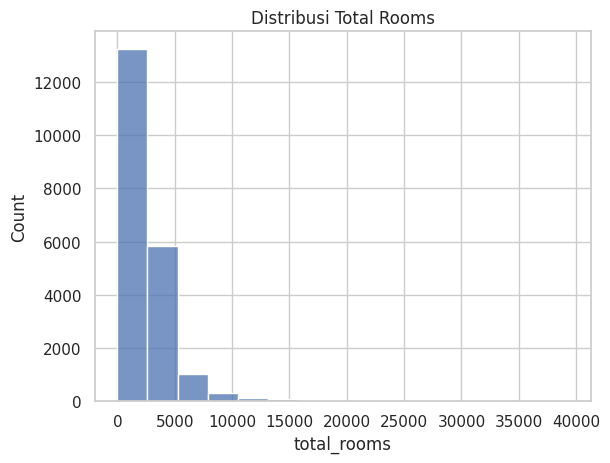

In [9]:
# Melihat distribusi jumlah ruangan
sns.histplot(data=df, x='total_rooms', bins=15)

plt.title('Distribusi Total Rooms')
plt.show()

Penjelasan: Kode ini membuat histogram untuk melihat penyebaran jumlah ruangan pada kolom total_rooms.

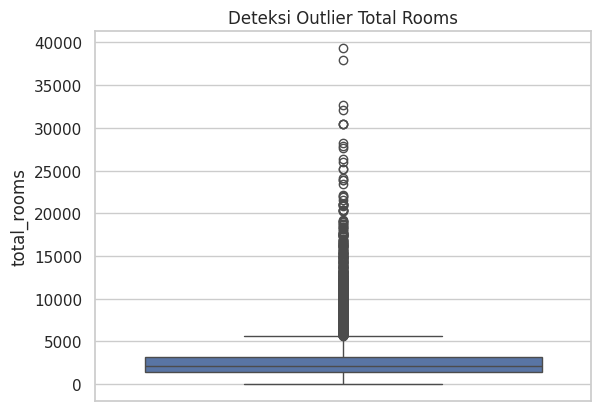

In [10]:
# Membuat boxplot untuk melihat outlier pada total_rooms
sns.boxplot(data=df, y='total_rooms')

plt.title('Deteksi Outlier Total Rooms')
plt.show()

Penjelasan: Kode ini membuat boxplot untuk melihat distribusi jumlah ruangan dan mendeteksi kemungkinan adanya outlier.

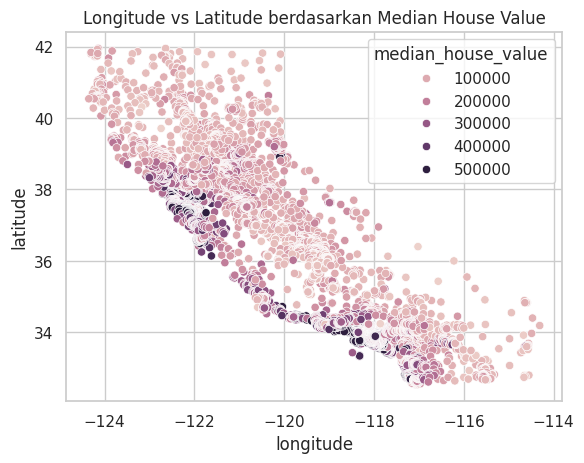

In [11]:
# Membuat scatter plot berdasarkan longitude dan latitude
# Warna menunjukkan nilai median house value
sns.scatterplot(
    data=df,
    x='longitude',
    y='latitude',
    hue='median_house_value'
)

plt.title('Longitude vs Latitude berdasarkan Median House Value')
plt.show()

Penjelasan: Kode ini membuat grafik persebaran lokasi rumah berdasarkan longitude dan latitude, dengan warna yang menunjukkan nilai harga rumah.

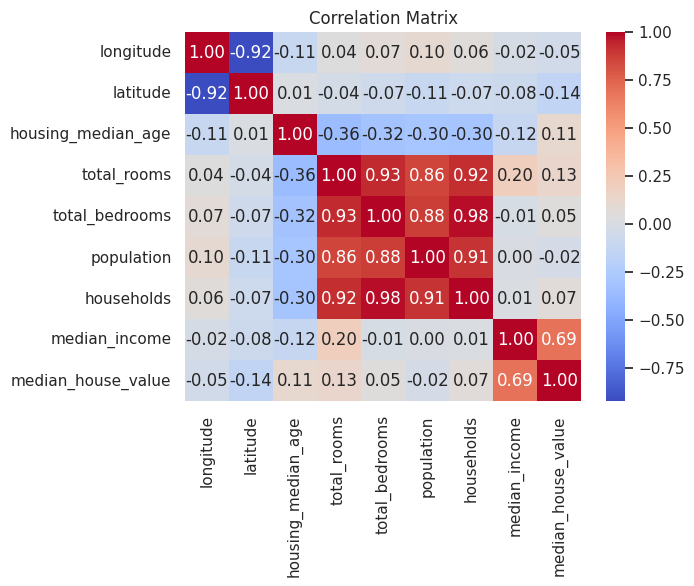

In [12]:
# Mengambil kolom yang memiliki tipe data numerik
num = df.select_dtypes(include='number')

# Membuat correlation matrix
sns.heatmap(
    num.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

Penjelasan: Kode ini membuat Heatmap, correlation matrix untuk melihat hubungan atau korelasi antarvariabel numerik dalam dataset.

#2. Pre-processing

In [13]:
from sklearn.impute import SimpleImputer

# Membuat imputer dengan metode median
imputer = SimpleImputer(strategy='median')

# Mengisi nilai kosong pada total_bedrooms
# menggunakan nilai median
df['total_bedrooms'] = imputer.fit_transform(
    df[['total_bedrooms']]
).ravel()

# Mengecek jumlah nilai kosong pada setiap kolom
print("Jumlah nilai hilang:")
print(df.isnull().sum())

Jumlah nilai hilang:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


Penjelasan: Kode ini menangani data kosong pada total_bedrooms dengan menggantinya menggunakan nilai median, kemudian mengecek kembali jumlah data yang masih kosong.

In [14]:
# X berisi semua variabel input
# kecuali median_house_value
X = df.drop('median_house_value', axis=1)

# y berisi variabel yang ingin diprediksi
y = df['median_house_value']

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (20640, 9)
Shape y: (20640,)


Penjelasan: Kode ini memisahkan data menjadi X sebagai fitur input dan y sebagai target yang ingin diprediksi, yaitu median_house_value.

In [15]:
X = pd.get_dummies(
    X,
    columns=['ocean_proximity'],
    dtype=int
)

print(X.head())
print(X.dtypes)

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  ocean_proximity_<1H OCEAN  \
0       322.0       126.0         8.3252                          0   
1      2401.0      1138.0         8.3014                          0   
2       496.0       177.0         7.2574                          0   
3       558.0       219.0         5.6431                          0   
4       565.0       259.0         3.8462                          0   

   ocean_proximity_INLAND  ocean_proximity_ISLAND  ocean_proximity_NEAR BAY  \
0                       0                  

Penjelasan: Kode ini mengubah data kategori pada ocean_proximity menjadi data numerik menggunakan One-Hot Encoding agar dapat digunakan oleh model.

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Data latih:", X_train.shape)
print("Data uji:", X_test.shape)

Data latih: (16512, 13)
Data uji: (4128, 13)


Penjelasan: Kode ini membagi dataset menjadi data training sebesar 80% dan data testing sebesar 20% untuk melatih dan menguji model.

In [17]:
from sklearn.preprocessing import StandardScaler

# Membuat objek StandardScaler
scaler = StandardScaler()

# Menghitung parameter scaling dari data training
# kemudian melakukan standardisasi
X_train_scaled = scaler.fit_transform(X_train)

# Menggunakan parameter dari data training
# untuk melakukan standardisasi pada data testing
X_test_scaled = scaler.transform(X_test)

Penjelasan: Kode ini melakukan standardisasi pada fitur agar skala setiap variabel menjadi lebih seragam sebelum digunakan dalam model.

In [18]:
print("Missing value X_train:", np.isnan(X_train_scaled).sum())
print("Missing value X_test :", np.isnan(X_test_scaled).sum())

Missing value X_train: 0
Missing value X_test : 0


Penjelasan: Kode ini mengecek apakah masih terdapat nilai kosong atau NaN pada data training dan testing setelah preprocessing.

In [19]:
print("Semua fitur numerik:", X.dtypes.apply(
    lambda x: np.issubdtype(x, np.number)
).all())

Semua fitur numerik: True


Penjelasan: Kode ini memastikan seluruh fitur pada dataset sudah memiliki tipe data numerik sehingga dapat diproses oleh model.

In [20]:
print("Rata-rata X_train:")
print(X_train_scaled.mean(axis=0))

print("\nStandar deviasi X_train:")
print(X_train_scaled.std(axis=0))

Rata-rata X_train:
[ 1.75333477e-15  6.40099515e-17 -9.25185854e-18  3.37800416e-17
 -4.59365534e-17 -2.15159501e-19 -5.42201942e-17 -6.51933288e-17
  9.29489044e-17 -5.80930652e-18 -7.74574203e-18 -1.68900208e-17
 -1.14572434e-17]

Standar deviasi X_train:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


Penjelasan: Kode ini digunakan untuk mengecek hasil standardisasi dengan melihat rata-rata dan standar deviasi dari data training.

#3. Regresi

In [21]:
from sklearn.linear_model import LinearRegression
# Membuat model Linear Regression
model = LinearRegression()

Penjelasan: Kode ini membuat model Linear Regression yang nantinya akan dilatih menggunakan data training.

In [22]:
# Melatih model menggunakan data training
model.fit(X_train_scaled, y_train)

LinearRegression()

Penjelasan: Kode ini melatih model menggunakan data training agar model dapat mempelajari hubungan antara fitur rumah dan harga rumah.

In [23]:
# Melakukan prediksi menggunakan data testing
y_pred = model.predict(X_test_scaled)

Penjelasan: Kode ini menggunakan model yang sudah dilatih untuk memprediksi harga rumah berdasarkan data testing.

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Menghitung MAE
mae = mean_absolute_error(y_test, y_pred)

# Menghitung MSE
mse = mean_squared_error(y_test, y_pred)

# Menghitung RMSE
rmse = np.sqrt(mse)

# Menghitung R-squared
r2 = r2_score(y_test, y_pred)

print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R²   :", r2)

MAE  : 50670.73824097191
MSE  : 4908476721.156616
RMSE : 70060.52184473518
R²   : 0.6254240620553606


Penjelasan: Kode ini mengevaluasi hasil prediksi model menggunakan MAE, MSE, RMSE, dan R² untuk mengetahui seberapa baik performa model dalam memprediksi harga rumah.

In [25]:
hasil = pd.DataFrame({
    'Aktual': y_test.values,
    'Prediksi': y_pred
})

print(hasil.head(10))

     Aktual       Prediksi
0   47700.0   54055.448899
1   45800.0  124225.338937
2  500001.0  255489.379492
3  218600.0  268002.431569
4  278000.0  262769.434816
5  158700.0  139606.303956
6  198200.0  290665.423914
7  157500.0  228264.876375
8  340000.0  256506.785610
9  446600.0  407923.858435


Penjelasan: Kode ini membuat tabel yang membandingkan nilai harga rumah sebenarnya dengan nilai yang diprediksi oleh model.

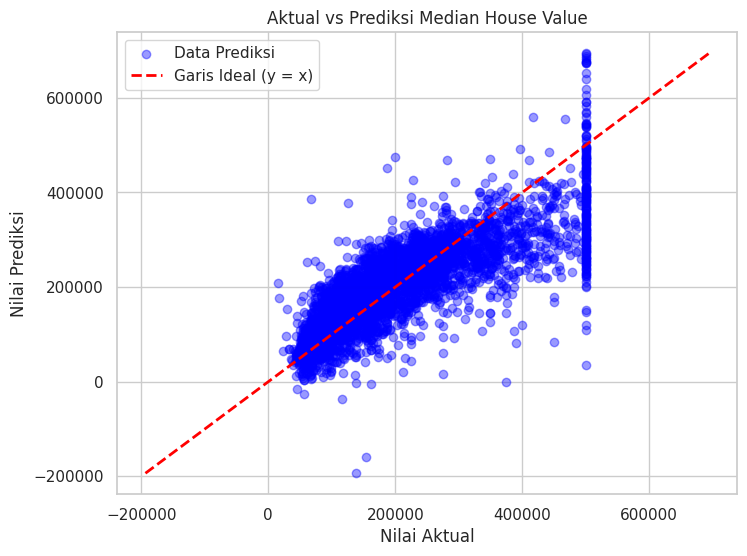

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Plot titik data aktual vs prediksi
plt.scatter(y_test, y_pred, alpha=0.4, color='blue', label='Data Prediksi')

# Garis ini ditarik dari nilai minimum terkecil sampai nilai maksimum terbesar
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color='red',
    linestyle='--',
    linewidth=2,
    label='Garis Ideal (y = x)',
)

plt.xlabel('Nilai Aktual')
plt.ylabel('Nilai Prediksi')
plt.title('Aktual vs Prediksi Median House Value')
plt.legend()
plt.show()

Penjelasan: Kode ini membuat grafik perbandingan antara nilai aktual dan nilai prediksi untuk melihat secara visual seberapa dekat hasil prediksi model dengan nilai sebenarnya.